In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shutil
import os

In [3]:
os.makedirs("../data/processed", exist_ok=True)
shutil.copy(
    "../data/raw/smartcity.csv",
    "../data/processed/smartcity_processed.csv"
)

print("Dataset copied successfully!")

Dataset copied successfully!


In [4]:
df = pd.read_csv("../data/processed/smartcity_processed.csv")

print("Rows, Columns:", df.shape)

df

Rows, Columns: (100800, 18)


,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action
0,SC0000000,North,Road,2024-05-17,24.6,57.2,17.39,56.8,201.9,71.0,5.01,24.5,3,9,46.5,Medium Risk,5372.51,Schedule inspection
1,SC0000001,West,StreetLight,2024-11-03,23.6,61.0,10.26,27.1,186.1,77.0,4.81,50.7,4,330,47.6,Medium Risk,2139.25,Schedule inspection
2,SC0000002,West,AirStation,2024-11-11,16.4,37.1,4.04,17.9,143.7,197.0,2.75,31.1,3,14,32.3,Low Risk,2306.42,Monitor
3,SC0000003,East,TrafficLight,2024-10-02,30.5,57.1,26.49,27.8,142.1,92.0,3.91,72.2,6,582,87.1,Critical Risk,6393.78,Dispatch crew now
4,SC0000004,East,StreetLight,2024-10-06,20.9,92.1,37.64,60.0,109.5,57.0,2.71,13.8,7,77,100.0,Critical Risk,4258.07,Dispatch crew now
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
100795,SC0022290,East,StreetLight,2024-12-13,30.5,85.2,26.54,18.1,79.8,40.0,5.80,96.9,4,270,61.0,High Risk,2772.81,Plan maintenance
100796,SC0063883,West,TrafficLight,2024-12-02,3.9,29.8,1.36,11.5,153.3,109.0,4.57,16.2,3,481,58.3,Medium Risk,3088.39,Schedule inspection
100797,SC0045928,West,AirStation,2024-08-31,13.9,82.9,22.75,91.4,95.4,96.0,4.36,86.0,6,107,52.4,Medium Risk,3316.68,Schedule inspection
100798,SC0025003,North,Road,2024-05-22,21.5,61.0,51.80,64.6,77.8,82.0,6.32,32.7,2,529,100.0,Critical Risk,14488.08,Dispatch crew now


In [5]:
print("Dataset info:")
df.info()

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 100800 entries, 0 to 100799
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   sensor_id                  100800 non-null  str    
 1   district                   100800 non-null  str    
 2   asset_type                 100800 non-null  str    
 3   timestamp                  100800 non-null  str    
 4   temperature                97787 non-null   float64
 5   humidity                   97780 non-null   float64
 6   vibration_level            100800 non-null  float64
 7   traffic_density            100800 non-null  float64
 8   power_usage                100800 non-null  float64
 9   air_quality_index          100800 non-null  float64
 10  water_pressure             97776 non-null   float64
 11  battery_level              97781 non-null   float64
 12  maintenance_history_count  100800 non-null  int64  
 13  last_maintenance_days     

In [6]:
# missing values ne water_pressure, battery_level,   temperature , humidity
# 6 kolona string

In [7]:
df.describe()

,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,estimated_repair_cost
count,97787.000000,97780.00000,100800.000000,100800.000000,100800.000000,100800.000000,97776.000000,97781.000000,100800.000000,100800.000000,100800.000000,100800.000000
mean,26.057374,57.42680,15.980173,50.023811,140.211564,75.099742,4.503726,52.529642,2.999643,359.613879,57.753063,5581.718484
std,63.381080,21.64005,11.264761,28.835836,45.010920,43.356928,1.197210,27.354843,1.731103,207.979615,19.984983,4459.246175
min,-22.400000,20.00000,0.060000,0.000000,-49.700000,1.000000,-1.010000,5.000000,0.000000,0.000000,0.000000,50.000000
25%,16.000000,38.70000,7.700000,25.000000,110.100000,43.000000,3.700000,29.000000,2.000000,180.000000,43.400000,2649.830000
50%,22.100000,57.40000,13.420000,49.950000,140.100000,67.000000,4.500000,52.400000,3.000000,360.000000,56.600000,4115.100000
75%,28.100000,76.10000,21.640000,75.100000,170.700000,98.000000,5.310000,76.300000,4.000000,540.000000,71.100000,6477.827500
max,999.000000,95.00000,114.920000,100.000000,328.800000,429.000000,10.030000,100.000000,14.000000,719.000000,100.000000,26065.420000


### temperatura ka max 999 !!!!! DONE
### vibration duket si outlier, por ne fakt po jep informata per sensora , LEJOHET- DONE
### power usage ka vlere negative min   DONE
### water pressure vlere neg DONE

In [8]:
print("Missing values:")
df.isna().sum()

Missing values:


sensor_id                       0
district                        0
asset_type                      0
timestamp                       0
temperature                  3013
humidity                     3020
vibration_level                 0
traffic_density                 0
power_usage                     0
air_quality_index               0
water_pressure               3024
battery_level                3019
maintenance_history_count       0
last_maintenance_days           0
anomaly_score                   0
failure_risk_level              0
estimated_repair_cost           0
recommended_action              0
dtype: int64

# missing values ne water_pressure, battery_level,   temperature , humidity

In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 800


In [10]:
duplicates = df[df.duplicated(keep=False)].sort_values(by="sensor_id")
print(duplicates)

        sensor_id district    asset_type   timestamp  temperature  humidity  \
312     SC0000312    North   StreetLight  2024-01-31         15.5      37.6   
100551  SC0000312    North   StreetLight  2024-01-31         15.5      37.6   
385     SC0000385    North          Road  2024-01-24         17.0      72.4   
100181  SC0000385    North          Road  2024-01-24         17.0      72.4   
422     SC0000422     West   WaterSystem  2024-07-30         17.3      64.3   
...           ...      ...           ...         ...          ...       ...   
99608   SC0099608    South          Road  2024-08-11         26.2      60.4   
100140  SC0099624  Central  TrafficLight  2024-09-30         12.8       NaN   
99624   SC0099624  Central  TrafficLight  2024-09-30         12.8       NaN   
100500  SC0099818     East   WaterSystem  2024-06-03         27.6      28.2   
99818   SC0099818     East   WaterSystem  2024-06-03         27.6      28.2   

        vibration_level  traffic_density  power_usa

# Fshirja e Duplicates

In [11]:
df = df.drop_duplicates()
print("Duplicate rows after cleaning:", df.duplicated().sum())

Duplicate rows after cleaning: 0


In [12]:
df.shape

(100000, 18)

In [13]:
df.to_csv(
    "../data/processed/smartcity_processed.csv",
    index=False
)

print("Dataset saved.")

Dataset saved.


### Rregullimi i datasetit sipas kolonave

In [14]:
df[df["temperature"] > 100]

,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action
37,SC0000037,Central,WaterSystem,2024-01-13,999.0,88.9,19.21,77.3,168.6,111.0,5.24,81.1,2,581,69.8,High Risk,10446.98,Plan maintenance
507,SC0000507,South,AirStation,2024-10-17,999.0,29.7,7.18,87.6,114.8,116.0,NaN,32.5,2,257,40.5,Medium Risk,2808.07,Schedule inspection
752,SC0000752,NORTH,Bridge,2024-06-02,999.0,82.3,2.74,28.7,184.3,91.0,3.35,96.4,3,382,24.5,Low Risk,5977.92,Monitor
843,SC0000843,North,StreetLight,2024-03-14,999.0,33.8,17.53,53.1,154.0,73.0,5.90,63.2,3,399,54.7,Medium Risk,2158.97,Schedule inspection
1273,SC0001273,West,Road,18/09/2024,999.0,34.4,12.86,66.9,113.4,29.0,4.06,66.7,2,550,57.5,Medium Risk,5960.01,Schedule inspection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99002,SC0099002,South,TrafficLight,2024-03-22,999.0,86.3,38.59,52.0,172.3,52.0,4.81,74.8,2,404,91.0,Critical Risk,6249.30,Dispatch crew now
99003,SC0099003,East,StreetLight,2024-06-03,999.0,44.9,9.15,53.4,188.9,21.0,3.59,NaN,4,541,56.1,Medium Risk,2305.80,Schedule inspection
99725,SC0099725,South,StreetLight,2024-04-14,999.0,39.9,17.49,94.8,80.9,23.0,NaN,80.8,4,236,56.0,Medium Risk,2048.12,Schedule inspection
99789,SC0099789,South,TrafficLight,01/09/2024,999.0,27.6,8.63,90.9,169.2,104.0,1.86,44.9,1,69,29.7,Low Risk,1678.39,Monitor


In [15]:
df["temperature"].sort_values().head(20)

#per vlera min ka logjike

2988    -22.4
30300   -14.9
4016    -14.9
23781   -14.8
15959   -14.5
66275   -13.2
13283   -12.9
56152   -12.5
47563   -12.1
92833   -11.6
34629   -10.9
91812   -10.6
84643   -10.5
5961    -10.5
49355   -10.4
33592   -10.2
67338   -10.2
80475    -9.9
36722    -9.9
6091     -9.8
Name: temperature, dtype: float64

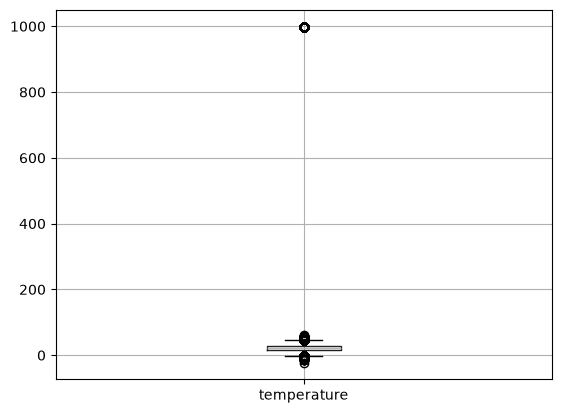

In [16]:
df.boxplot(column="temperature")
plt.show()

In [17]:
# Pastrimi i temperatures
df.loc[df["temperature"] == 999, "temperature"] = np.nan

In [18]:
df[df["vibration_level"] > 90]

,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action
3363,SC0003363,Central,TrafficLight,2024-01-27,26.8,33.2,94.03,57.9,145.9,50.0,3.51,67.4,3,407,100.0,Critical Risk,6865.72,Dispatch crew now
9517,SC0009517,North,StreetLight,2024-03-24,18.3,30.6,98.57,74.8,104.6,61.0,4.29,94.6,5,194,100.0,Critical Risk,4349.03,Dispatch crew now
24789,SC0024789,North,WaterSystem,2024-11-06,23.2,77.3,90.04,91.9,100.6,59.0,5.22,33.5,2,49,100.0,Critical Risk,16452.30,Dispatch crew now
28756,SC0028756,North,WaterSystem,2024-07-03,13.2,32.6,106.23,71.3,127.1,93.0,4.53,29.8,3,581,100.0,Critical Risk,16698.05,Dispatch crew now
30387,SC0030387,South,Bridge,2024-04-19,23.5,55.2,92.37,14.4,108.0,63.0,3.65,7.0,6,172,100.0,Critical Risk,25607.31,Dispatch crew now
36868,SC0036868,Central,AirStation,2024-11-01,NaN,91.4,95.96,45.3,99.0,49.0,5.43,57.4,2,655,100.0,Critical Risk,8473.45,Dispatch crew now
47296,SC0047296,Central,TrafficLight,2024-03-01,14.3,32.2,93.24,52.0,162.5,45.0,7.25,42.5,2,147,100.0,Critical Risk,6392.69,Dispatch crew now
48713,SC0048713,Central,StreetLight,16/11/2024,25.5,76.0,93.41,40.2,212.0,96.0,3.38,85.1,5,171,100.0,Critical Risk,4508.90,Dispatch crew now
54966,SC0054966,South,StreetLight,2024-01-05,22.9,59.3,114.92,31.7,122.3,52.0,5.77,76.5,3,644,100.0,Critical Risk,4338.16,Dispatch crew now
76478,SC0076478,South,StreetLight,2024-09-26,34.5,73.1,92.14,57.3,173.5,59.0,3.99,NaN,5,340,100.0,Critical Risk,4233.19,Dispatch crew now


In [19]:
df[df["vibration_level"] > 90][["vibration_level", "anomaly_score"]]

#ka kuptim, eshte ne rregull

,vibration_level,anomaly_score
3363,94.03,100.0
9517,98.57,100.0
24789,90.04,100.0
28756,106.23,100.0
30387,92.37,100.0
36868,95.96,100.0
47296,93.24,100.0
48713,93.41,100.0
54966,114.92,100.0
76478,92.14,100.0


In [20]:
# power usage neg
df[df["power_usage"] < 0]


,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action
1110,SC0001110,West,StreetLight,2024-08-31,27.9,42.9,23.97,14.4,-23.0,91.0,5.79,60.5,0,567,63.2,High Risk,2645.63,Plan maintenance
3076,SC0003076,North,TrafficLight,2024-01-17,30.7,23.5,14.58,53.3,-12.7,95.0,5.29,35.1,4,586,70.8,High Risk,4296.04,Plan maintenance
4131,SC0004131,Central,TrafficLight,2024-11-14,41.1,88.9,6.85,47.6,-12.0,107.0,1.83,NaN,4,251,36.5,Low Risk,2149.18,Monitor
6004,SC0006004,East,TrafficLight,2024-08-12,NaN,51.7,17.27,54.2,-11.4,179.0,4.60,9.5,4,102,60.0,Medium Risk,2930.64,Schedule inspection
6597,SC0006597,East,Road,30/03/2024,21.0,74.4,17.86,46.9,-29.5,65.0,3.78,93.3,5,55,38.7,Low Risk,3817.26,Monitor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94220,SC0094220,West,WaterSystem,18/11/2024,11.4,68.2,12.50,73.0,-10.6,20.0,2.68,41.1,3,39,40.7,Medium Risk,6282.72,Schedule inspection
94256,SC0094256,North,Road,2024-11-14,28.0,41.3,57.06,25.7,-37.7,112.0,NaN,66.7,1,475,100.0,Critical Risk,14357.60,Dispatch crew now
96622,SC0096622,North,StreetLight,2024-12-11,7.7,89.3,17.23,33.5,-23.4,149.0,5.39,86.6,1,613,64.6,High Risk,2892.67,Plan maintenance
98136,SC0098136,South,TrafficLight,2024-07-04,37.3,59.4,20.16,49.6,-4.9,153.0,4.59,NaN,4,442,65.1,High Risk,4253.65,Plan maintenance


In [21]:
# Pastrimi i power usage
df.loc[df["power_usage"] < 0, "power_usage"] = np.nan

In [22]:
df[df["power_usage"] < 0]

#jane larguar vlerat negative

,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action


In [23]:
df[df["water_pressure"] < 0]

,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action
420,SC0000420,Central,Bridge,2024-12-28,33.9,21.4,41.78,35.1,132.3,82.0,-0.51,49.6,3,506,100.0,Critical Risk,25592.40,Dispatch crew now
30021,SC0030021,North,Road,2024-08-24,24.1,44.7,23.82,12.1,180.6,113.0,-0.42,97.6,3,330,47.9,Medium Risk,5457.31,Schedule inspection
40118,SC0040118,West,AirStation,2024-06-25,12.7,74.7,17.61,90.8,203.7,36.0,-0.18,69.2,3,686,75.2,High Risk,5809.22,Plan maintenance
76220,SC0076220,South,Bridge,2024-07-13,24.6,91.0,9.28,76.4,134.2,82.0,-0.20,15.4,3,266,47.8,Medium Risk,9606.03,Schedule inspection
89523,SC0089523,East,TrafficLight,2024-10-12,25.0,50.0,14.48,85.7,112.0,31.0,-0.30,12.9,1,458,57.6,Medium Risk,3050.58,Schedule inspection
93994,SC0093994,East,StreetLight,2024-09-10,8.5,31.9,11.30,73.6,140.6,130.0,-1.01,75.4,3,374,39.5,Low Risk,1343.80,Monitor
95414,SC0095414,North,Road,2024-06-02,36.1,45.3,35.47,46.5,169.7,194.0,-0.07,43.6,0,574,100.0,Critical Risk,14130.43,Dispatch crew now
97346,SC0097346,North,TrafficLight,2024-07-03,8.8,71.6,7.91,33.9,129.8,41.0,-0.42,79.5,2,113,21.7,Low Risk,1417.98,Monitor


In [24]:
# Pastrimi i power usage
df.loc[df["water_pressure"] < 0, "water_pressure"] = np.nan

In [25]:
df[df["water_pressure"] < 0]


#water pressure u rregullua

,sensor_id,district,asset_type,timestamp,temperature,humidity,vibration_level,traffic_density,power_usage,air_quality_index,water_pressure,battery_level,maintenance_history_count,last_maintenance_days,anomaly_score,failure_risk_level,estimated_repair_cost,recommended_action


### Kolonat string dhe timestamp

In [26]:
df["district"].unique()

<StringArray>
['North', 'West', 'East', 'Central', 'south', 'South', 'north', 'NORTH']
Length: 8, dtype: str

In [27]:
df["district"] = df["district"].astype(str).str.strip().str.title()
df["district"].unique()

#DONE

<StringArray>
['North', 'West', 'East', 'Central', 'South']
Length: 5, dtype: str

In [28]:
df["asset_type"].unique()

<StringArray>
['Road', 'StreetLight', 'AirStation', 'TrafficLight', 'Bridge', 'WaterSystem']
Length: 6, dtype: str

In [29]:

df["failure_risk_level"].unique()

<StringArray>
['Medium Risk', 'Low Risk', 'Critical Risk', 'High Risk']
Length: 4, dtype: str

In [30]:
df["recommended_action"].unique()

<StringArray>
['Schedule inspection', 'Monitor', 'Dispatch crew now', 'Plan maintenance']
Length: 4, dtype: str

In [31]:
df["timestamp"] = pd.to_datetime(df["timestamp"], format="mixed",
                                 dayfirst=True, errors="coerce")

In [32]:
df["timestamp"].unique()

#u kthye ne DATETIME

<DatetimeArray>
['2024-05-17 00:00:00', '2024-03-11 00:00:00', '2024-11-11 00:00:00',
 '2024-02-10 00:00:00', '2024-06-10 00:00:00', '2024-01-07 00:00:00',
 '2024-03-24 00:00:00', '2024-07-08 00:00:00', '2024-12-27 00:00:00',
 '2024-09-24 00:00:00',
 ...
 '2024-12-09 00:00:00', '2024-02-18 00:00:00', '2024-05-16 00:00:00',
 '2024-11-04 00:00:00', '2024-11-14 00:00:00', '2024-10-03 00:00:00',
 '2024-07-15 00:00:00', '2024-04-04 00:00:00', '2024-07-20 00:00:00',
 '2024-08-08 00:00:00']
Length: 365, dtype: datetime64[us]

In [33]:
for col in ["temperature", "power_usage", "water_pressure"]:
    df[col] = df[col].fillna(df[col].median())


In [34]:
for col in ["humidity", "battery_level"]:
    df[col] = df[col].fillna(df[col].median())


In [35]:
df.info()

# U MBUSH DATASETI

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   sensor_id                  100000 non-null  str           
 1   district                   100000 non-null  str           
 2   asset_type                 100000 non-null  str           
 3   timestamp                  100000 non-null  datetime64[us]
 4   temperature                100000 non-null  float64       
 5   humidity                   100000 non-null  float64       
 6   vibration_level            100000 non-null  float64       
 7   traffic_density            100000 non-null  float64       
 8   power_usage                100000 non-null  float64       
 9   air_quality_index          100000 non-null  float64       
 10  water_pressure             100000 non-null  float64       
 11  battery_level              100000 non-null  float64       
 12  

In [36]:
df.to_csv(
    "../data/processed/smartcity_processed.csv",
    index=False
)

print("Processed dataset saved successfully!")

Processed dataset saved successfully!


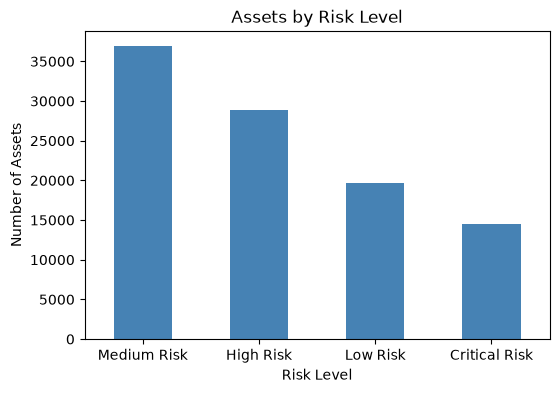

In [37]:
#Bar Chart per rrezikun
plt.figure(figsize=(6,4))

df["failure_risk_level"].value_counts().plot(
    kind="bar",
    color="steelblue"
)

plt.title("Assets by Risk Level")
plt.xlabel("Risk Level")
plt.ylabel("Number of Assets")
plt.xticks(rotation=0)
plt.show()

### Most assets are Medium Risk, while Critical Risk assets are fewer.

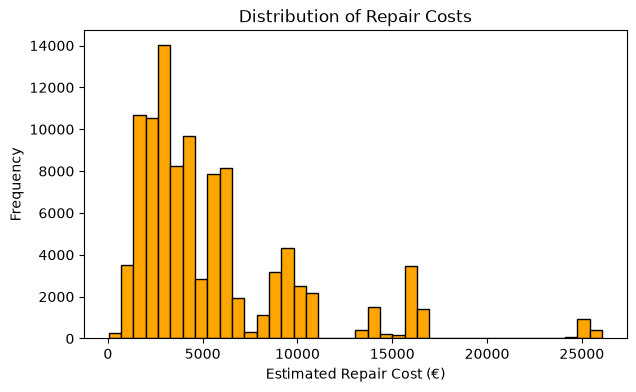

In [38]:
# Histogram per Kosto te riparimit
plt.figure(figsize=(7,4))

df["estimated_repair_cost"].plot(
    kind="hist",
    bins=40,
    color="orange",
    edgecolor="black"
)

plt.title("Distribution of Repair Costs")
plt.xlabel("Estimated Repair Cost (€)")
plt.ylabel("Frequency")
plt.show()

### Histogrami tregon se shumica e kostove të riparimit janë të përqendruara në intervalin 2,000–6,000 €, ndërsa me rritjen e kostos frekuenca zvogëlohet. Vërehen edhe disa vlera shumë të larta (rreth 15,000 € dhe 25,000 €), të cilat paraqesin raste të rralla ose outliers. Shpërndarja nuk është normale, por është e anuar majtas (left-skewed).

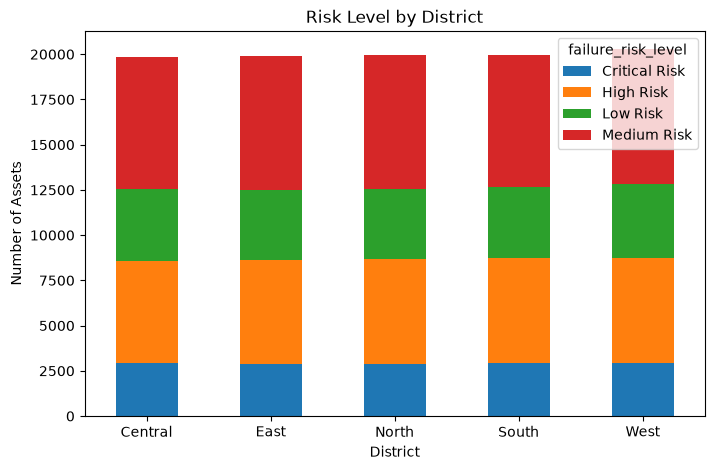

In [39]:
# Stacked Bar risks sipas distrikteve
risk = (
    df.groupby("district")["failure_risk_level"]
      .value_counts()
      .unstack()
)

risk.plot(
    kind="bar",
    stacked=True,
    figsize=(8,5)
)

plt.title("Risk Level by District")
plt.xlabel("District")
plt.ylabel("Number of Assets")
plt.xticks(rotation=0)
plt.show()

### Grafiku tregon se shpërndarja e niveleve të rrezikut është pothuajse e njëjtë në të gjitha distriktet (Central, East, North, South dhe West). Në secilin distrikt dominon niveli i rrezikut mesatar (Medium Risk), i ndjekur nga rreziku i lartë (High Risk), ndërsa rreziku kritik (Critical Risk) është më pak i shpeshtë. Kjo tregon se nuk ka dallime të konsiderueshme ndërmjet distrikteve për sa i përket shpërndarjes së niveleve të rrezikut.

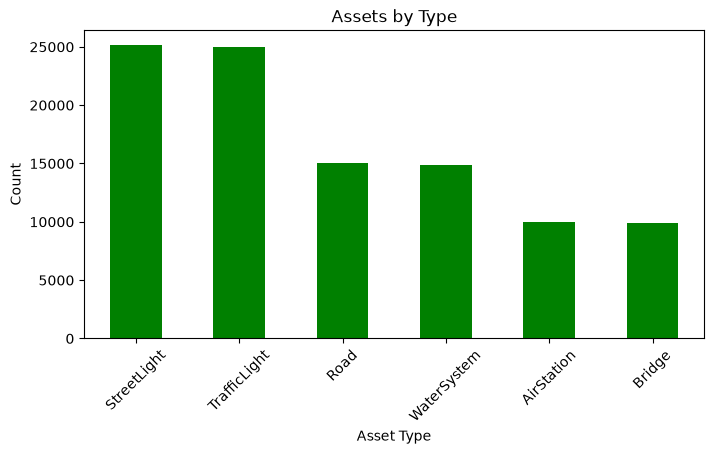

In [40]:
# Asset Type 
plt.figure(figsize=(8,4))

df["asset_type"].value_counts().plot(
    kind="bar",
    color="green"
)

plt.title("Assets by Type")
plt.xlabel("Asset Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Grafiku paraqet numrin e aseteve sipas llojit. Numrin më të madh e kanë StreetLight dhe TrafficLight, me rreth 25,000 asete secila. Road dhe WaterSystem përfaqësohen me rreth 15,000 asete, ndërsa AirStation dhe Bridge kanë numrin më të vogël, me rreth 10,000 asete secila. Kjo tregon se ndriçimi rrugor dhe semaforët përbëjnë pjesën më të madhe të infrastrukturës në dataset.

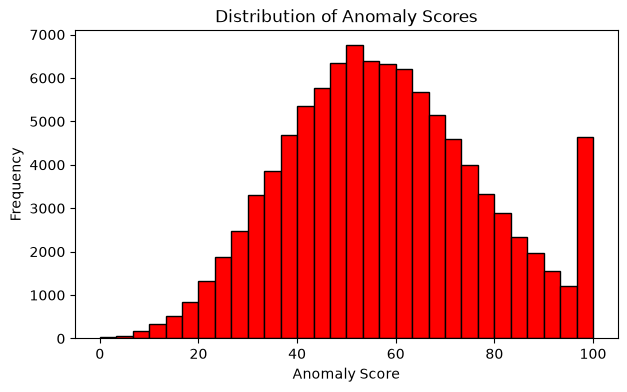

In [41]:
# Anomaly Score Distribution
plt.figure(figsize=(7,4))

df["anomaly_score"].plot(
    kind="hist",
    bins=30,
    color="red",
    edgecolor="black"
)

plt.title("Distribution of Anomaly Scores")
plt.xlabel("Anomaly Score")
plt.ylabel("Frequency")
plt.show()

### Histogrami paraqet shpërndarjen e pikëve të anomalive (Anomaly Score). Shumica e vlerave janë të përqendruara rreth intervalit 40–70, me kulmin afër vlerës 50, duke treguar se shumica e aseteve kanë nivel mesatar anomalie. Vërehet gjithashtu një numër i konsiderueshëm rastesh me vlerën maksimale 100, që mund të përfaqësojnë asete me rrezik shumë të lartë ose anomali kritike.